# Baseball Detection Project

This notebook builds an object detection pipeline for identifying baseballs in training video frames. The workflow includes loading the videos and XML annotations, extracting video frames, converting annotations into a structured dataset, training a Faster R-CNN object detection model, and visualizing prediction results.

**Note:** Training is demonstrated on a subset of the data to ensure the notebook runs efficiently on a local machine while still validating the full object detection pipeline.

#### 1. Import Libraries and Setup
#### 2. Load and Verify Data
#### 3. Extract Frames from Videos
#### 4. Process Annotations
#### 5. Build Dataset
#### 6. Train-Test Split
#### 7. DataLoader Setup
#### 8. Model Setup
#### 9. Training (Demonstration Run)
#### 10. Prediction
#### 11. Visualization of Results

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Import required libraries for file handling, data processing, image processing, visualization, and modeling
from pathlib import Path
import os
import cv2
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from sklearn.model_selection import train_test_split


# Define folders for videos, annotations, and extracted frames
PROJECT_DIR = Path("/content/drive/MyDrive/BaseballDetection")
VIDEOS_DIR = Path("/content/drive/MyDrive/videos_final")
ANNOTATIONS_DIR = Path("/content/drive/MyDrive/annotations_final")
FRAMES_DIR = Path("/content/drive/MyDrive/frames")

# Create frames folder if it does not already exist
FRAMES_DIR.mkdir(exist_ok=True)

# Check that the required folders exist
print("Project folder:", PROJECT_DIR)
print("Videos folder exists:", VIDEOS_DIR.exists())
print("Annotations folder exists:", ANNOTATIONS_DIR.exists())
print("Frames folder exists:", FRAMES_DIR.exists())

Project folder: /content/drive/MyDrive/BaseballDetection
Videos folder exists: True
Annotations folder exists: True
Frames folder exists: True


In [8]:
# Collect all video and annotation files
video_files = sorted(VIDEOS_DIR.glob("*.mov"))
annotation_files = sorted(ANNOTATIONS_DIR.glob("*.xml"))

# Compare file names without extensions
video_names = {file.stem for file in video_files}
annotation_names = {file.stem for file in annotation_files}

missing_annotations = sorted(video_names - annotation_names)
extra_annotations = sorted(annotation_names - video_names)

print("Number of videos:", len(video_files))
print("Number of annotations:", len(annotation_files))
print("Missing annotations:", missing_annotations)
print("Extra annotations:", extra_annotations)

Number of videos: 64
Number of annotations: 64
Missing annotations: []
Extra annotations: []


In [23]:
# Function to extract frames from each video and save them as image files
def extract_frames(video_path, output_dir):
    # Open the video file
    cap = cv2.VideoCapture(str(video_path))
    frame_idx = 0

    # Create a separate folder for each video's frames
    video_name = video_path.stem
    video_out_dir = output_dir / video_name
    video_out_dir.mkdir(exist_ok=True)

    # Read and save each frame
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_file = video_out_dir / f"{video_name}_frame_{frame_idx:04d}.jpg"
        cv2.imwrite(str(frame_file), frame)
        frame_idx += 1

    # Close the video file
    cap.release()
    print(f"{video_name}: {frame_idx} frames extracted")


# Extract frames for all videos
for video_path in video_files:
    extract_frames(video_path, FRAMES_DIR)

IMG_0030: 48 frames extracted
IMG_0031: 50 frames extracted
IMG_0032: 51 frames extracted
IMG_0033: 50 frames extracted
IMG_0034: 52 frames extracted
IMG_0035: 52 frames extracted
IMG_0036: 49 frames extracted
IMG_0037: 48 frames extracted
IMG_0038: 51 frames extracted
IMG_0039: 54 frames extracted
IMG_0040: 57 frames extracted
IMG_0041: 50 frames extracted
IMG_0042: 52 frames extracted
IMG_0043: 48 frames extracted
IMG_0044: 56 frames extracted
IMG_0045: 60 frames extracted
IMG_0046: 54 frames extracted
IMG_0047: 48 frames extracted
IMG_0074: 100 frames extracted
IMG_0075: 80 frames extracted
IMG_0076: 59 frames extracted
IMG_0077: 92 frames extracted
IMG_0078: 94 frames extracted
IMG_0079: 80 frames extracted
IMG_0083: 57 frames extracted
IMG_0084: 62 frames extracted
IMG_0085: 42 frames extracted
IMG_0170: 72 frames extracted
IMG_0171: 51 frames extracted
IMG_0172: 69 frames extracted
IMG_7918_dusty: 76 frames extracted
IMG_7919_dusty: 50 frames extracted
IMG_7943_khem: 51 frames ex

In [24]:
# Parse all CVAT XML annotation files into one structured table
all_rows = []
parse_status = {"moving_true": 0, "moving_false": 0, "no_attribute": 0}

for xml_file in annotation_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for track in root.findall("track"):
        label = track.attrib["label"]
        track_id = track.attrib["id"]

        for box in track.findall("box"):
            # Skip boxes that are marked as outside the frame
            if box.attrib.get("outside") == "1":
                continue

            is_moving = False
            found_moving_attr = False

            for attr in box.findall("attribute"):
                if attr.attrib.get("name", "").strip().lower() == "moving":
                    found_moving_attr = True
                    value = (attr.text or "").strip().lower()
                    is_moving = value in ("true", "1", "yes")
                    break

            if not found_moving_attr:
                parse_status['no_attribute'] += 1
            elif is_moving:
                parse_status['moving_true'] += 1
            else:
                parse_status['moving_false'] += 1

            all_rows.append({
                "xml_file": xml_file.name,
                "track_id": track_id,
                "label": label,
                "frame": int(box.attrib["frame"]),
                "xtl": float(box.attrib["xtl"]),
                "ytl": float(box.attrib["ytl"]),
                "xbr": float(box.attrib["xbr"]),
                "ybr": float(box.attrib["ybr"]),
                "occluded": int(box.attrib.get("occluded", 0)),
                "moving": is_moving
            })

annotations_df = pd.DataFrame(all_rows)

print("Total annotation rows:", len(annotations_df))
print(f"Moving=True: {parse_status['moving_true']}")
print(f"Moving=False: {parse_status['moving_false']}")
print(f"No 'moving' attribute (defaulted to false): {parse_status['no_attribute']}")

annotations_df.head()

Total annotation rows: 24361
Moving=True: 1479
Moving=False: 22807
No 'moving' attribute (defaulted to false): 75


,xml_file,track_id,label,frame,xtl,ytl,xbr,ybr,occluded,moving
0,IMG_0030.xml,0,baseball,25,2100.1,1649.50,2160.00,1740.60,0,True
1,IMG_0030.xml,0,baseball,26,1512.0,1763.00,1734.00,1875.70,0,True
2,IMG_0030.xml,0,baseball,27,1730.6,1880.10,1931.34,1965.65,0,True
3,IMG_0031.xml,0,baseball,25,1854.0,1501.50,2076.20,1616.20,0,True
4,IMG_0031.xml,0,baseball,26,1273.8,1628.25,1488.50,1739.70,0,True


In [25]:
# Create the video name by removing the .xml extension
annotations_df["video_name"] = annotations_df["xml_file"].str.replace(".xml", "", regex=False)

# Create the expected image filename for each annotated frame
annotations_df["image_file"] = (
    annotations_df["video_name"]
    + "_frame_"
    + annotations_df["frame"].astype(str).str.zfill(4)
    + ".jpg"
)

# Create the full path to each extracted frame image
annotations_df["image_path"] = annotations_df.apply(
    lambda row: FRAMES_DIR / row["video_name"] / row["image_file"],
    axis=1
)

# Confirm that every annotation row points to an existing image file
annotations_df["image_exists"] = annotations_df["image_path"].apply(lambda path: path.exists())

print("Total annotation rows:", len(annotations_df))
print("Rows with existing images:", annotations_df["image_exists"].sum())
print("Missing images:", len(annotations_df) - annotations_df["image_exists"].sum())

annotations_df[["xml_file", "video_name", "frame", "image_file", "image_exists"]].head()

Total annotation rows: 24361
Rows with existing images: 24361
Missing images: 0


,xml_file,video_name,frame,image_file,image_exists
0,IMG_0030.xml,IMG_0030,25,IMG_0030_frame_0025.jpg,True
1,IMG_0030.xml,IMG_0030,26,IMG_0030_frame_0026.jpg,True
2,IMG_0030.xml,IMG_0030,27,IMG_0030_frame_0027.jpg,True
3,IMG_0031.xml,IMG_0031,25,IMG_0031_frame_0025.jpg,True
4,IMG_0031.xml,IMG_0031,26,IMG_0031_frame_0026.jpg,True


In [26]:
# Filter to only moving baseballs, static baseballs become "negatives"

moving_df = annotations_df[annotations_df["moving"]].copy()

print("Annotation rows after filtering for moving:", len(moving_df))

# building set of all annotated frames regardless of wether or not they have balls
all_annotated_frames = annotations_df[["image_path", "video_name"]].drop_duplicates()

#grouping moving boxes by image
moving_grouped = moving_df.groupby("image_path")

dataset = []

for _, row in all_annotated_frames.iterrows():
  image_path = row["image_path"]
  video_name = row["video_name"]

  if image_path in moving_grouped.groups:
    group = moving_grouped.get_group(image_path)
    boxes = group[["xtl", "ytl", "xbr", "ybr"]].values.tolist()
    labels = [1 for _ in boxes]
  else:
    #if frame has no moving baseballs, treat as a negative example
    boxes = []
    labels = []

  dataset.append({
        "image_path": image_path,
        "boxes": boxes,
        "labels": labels
    })

n_positive = sum(1 for item in dataset if len(item["boxes"]) > 0)
n_negative = sum(1 for item in dataset if len(item["boxes"]) == 0)

print(f"Total images: {len(dataset)}")
print(f"With moving baseballs (positive): {n_positive}")
print(f"Without moving baseballs (negative): {n_negative}")

Annotation rows after filtering for moving: 1479
Total images: 2820
With moving baseballs (positive): 1189
Without moving baseballs (negative): 1631


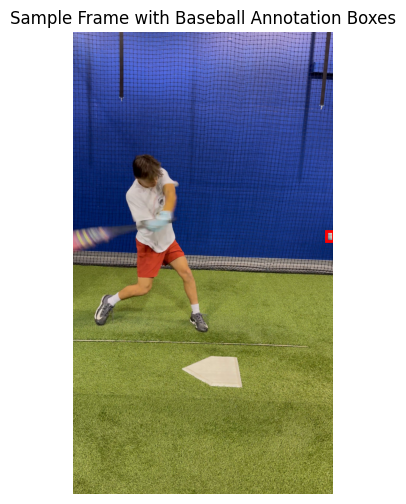

In [27]:
# Visualize one image with its annotation boxes to confirm the dataset was built correctly
sample = dataset[0]

image = Image.open(sample["image_path"])

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(image)

for box in sample["boxes"]:
    xtl, ytl, xbr, ybr = box
    width = xbr - xtl
    height = ybr - ytl

    rect = patches.Rectangle(
        (xtl, ytl),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

ax.set_title("Sample Frame with Baseball Annotation Boxes")
ax.axis("off")
plt.show()

In [28]:
# split by VIDEO so frames from the same clip don't leak between training/validation
all_videos = sorted(all_annotated_frames["video_name"].unique())

train_videos, val_videos = train_test_split(all_videos, test_size=0.2, random_state=42)

train_videos = set(train_videos)
val_videos = set(val_videos)

# Create a mapping from image_path to video_name for filtering the dataset
image_path_to_video_name = all_annotated_frames.set_index('image_path')['video_name'].to_dict()

train_data = [s for s in dataset if image_path_to_video_name[s["image_path"]] in train_videos]
val_data = [s for s in dataset if image_path_to_video_name[s["image_path"]] in val_videos]

print("Training videos:", len(train_videos))
print("Validation videos:", len(val_videos))
print("Training images:", len(train_data))
print("Validation images:", len(val_data))

Training videos: 51
Validation videos: 13
Training images: 2388
Validation images: 432


In [29]:
# sanity check, ensuring baseballs ended up in both sets
train_moving_boxes = sum(len(s["boxes"]) for s in train_data)
val_moving_boxes = sum(len(s["boxes"]) for s in val_data)

train_pos_frames = sum(1 for s in train_data if len(s["boxes"]) > 0)
val_pos_frames = sum(1 for s in val_data if len(s["boxes"]) > 0)

print("Train moving boxes:", train_moving_boxes)
print("Val moving boxes:", val_moving_boxes)

Train moving boxes: 1362
Val moving boxes: 117


In [30]:
# Custom PyTorch Dataset for baseball object detection
class BaseballDataset(Dataset):
    def __init__(self, data, resize_size=(640, 640)):
        self.data = data
        self.resize_size = resize_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        # Open image and convert to RGB
        image = Image.open(sample["image_path"]).convert("RGB")
        original_width, original_height = image.size


        image = image.resize((640, 640))
        image = F.to_tensor(image)


        new_width, new_height = self.resize_size


        scale_x = new_width / original_width
        scale_y = new_height / original_height

        # Handle frames with no objects
        if len(sample["boxes"]) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(sample["boxes"], dtype=torch.float32)

            # scale bounding boxes
            boxes[:, [0, 2]] *= scale_x
            boxes[:, [1, 3]] *= scale_y

            #converting image to tensor

            labels = torch.tensor(sample["labels"], dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return image, target


# Create training and validation datasets
train_dataset = BaseballDataset(train_data)
val_dataset = BaseballDataset(val_data)

# Test one item
image, target = train_dataset[0]

print("Image shape:", image.shape)
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"][:10])

Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([1, 4])
Labels: tensor([1])


In [31]:
# Custom collate function because each image may have a different number of bounding boxes
def collate_fn(batch):
    return tuple(zip(*batch))


# DataLoaders feed batches of images and annotation targets into the model
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# Test one batch
images, targets = next(iter(train_loader))

print("Number of images in batch:", len(images))
print("Image shape:", images[0].shape)
print("Boxes shape:", targets[0]["boxes"].shape)
print("Labels:", targets[0]["labels"][:10])

Number of images in batch: 2
Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([1, 4])
Labels: tensor([1])


In [32]:
# Use GPU if available; otherwise use CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("Using device:", device)

Using device: cuda


In [33]:
# Select GPU if available for faster training; otherwise fall back to CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [34]:
# Load a pretrained Faster R-CNN model for object detection
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# The model needs two classes: background and baseball
num_classes = 2

# Replace the classification head so the model predicts baseballs instead of COCO classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to the selected device
model.to(device)

print("Model ready on:", device)

Model ready on: cuda


In [35]:
train_dataset = BaseballDataset(train_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

print("Training images:", len(train_dataset))

Training images: 2388


In [36]:
# Load a pretrained Faster R-CNN model for object detection
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# The model needs two classes: background and baseball
num_classes = 2

# Replace the classification head so the model predicts baseballs instead of COCO classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to the selected device
model.to(device)

print("Model ready on:", device)

# Set up the optimizer to update model parameters during training
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,        # Learning rate controls the step size during training
    momentum=0.9,    # Momentum helps stabilize updates
    weight_decay=0.0005  # Weight decay helps reduce overfitting
)

# Train for one epoch as a demonstration run
num_epochs = 1

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if i % 10 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {losses.item():.4f}")

    print(f"Epoch {epoch+1} complete. Total loss: {total_loss:.4f}")

Model ready on: cuda
Epoch 1, Step 0, Loss: 1.4294
Epoch 1, Step 10, Loss: 0.0804
Epoch 1, Step 20, Loss: 0.0163
Epoch 1, Step 30, Loss: 0.1598
Epoch 1, Step 40, Loss: 0.1584
Epoch 1, Step 50, Loss: 0.0356
Epoch 1, Step 60, Loss: 0.1487
Epoch 1, Step 70, Loss: 0.1760
Epoch 1, Step 80, Loss: 0.1839
Epoch 1, Step 90, Loss: 0.2615
Epoch 1, Step 100, Loss: 0.0222
Epoch 1, Step 110, Loss: 1.4192
Epoch 1, Step 120, Loss: 0.2843
Epoch 1, Step 130, Loss: 0.0063
Epoch 1, Step 140, Loss: 0.2194
Epoch 1, Step 150, Loss: 0.2541
Epoch 1, Step 160, Loss: 0.1151
Epoch 1, Step 170, Loss: 0.1168
Epoch 1, Step 180, Loss: 0.1897
Epoch 1, Step 190, Loss: 0.1640
Epoch 1, Step 200, Loss: 0.4669
Epoch 1, Step 210, Loss: 0.2137
Epoch 1, Step 220, Loss: 0.3222
Epoch 1, Step 230, Loss: 0.0068
Epoch 1, Step 240, Loss: 0.0382
Epoch 1, Step 250, Loss: 0.3143
Epoch 1, Step 260, Loss: 0.0246
Epoch 1, Step 270, Loss: 0.0435
Epoch 1, Step 280, Loss: 0.0744
Epoch 1, Step 290, Loss: 0.2873
Epoch 1, Step 300, Loss: 0.117

In [37]:
# Switch model to evaluation mode for prediction
model.eval()

# Take one image from validation set
test_image, test_target = val_dataset[0]

# Run prediction (no gradient needed)
with torch.no_grad():
    prediction = model([test_image.to(device)])

# Show number of predictions
print("Number of predicted boxes:", len(prediction[0]["boxes"]))
print("Top scores:", prediction[0]["scores"][:5])

Number of predicted boxes: 4
Top scores: tensor([0.6785, 0.2061, 0.1181, 0.0559], device='cuda:0')


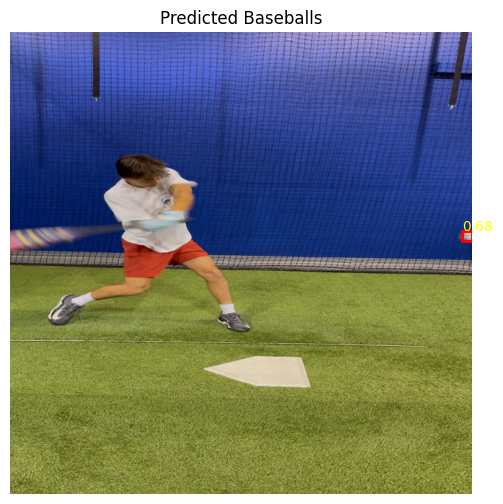

In [38]:
# Visualize prediction results

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Convert image to display format
img = test_image.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(img)

# Draw only high-confidence predictions
threshold = 0.5

boxes = prediction[0]["boxes"].cpu()
scores = prediction[0]["scores"].cpu()

for box, score in zip(boxes, scores):
    if score > threshold:
        xtl, ytl, xbr, ybr = box
        rect = patches.Rectangle(
            (xtl, ytl),
            xbr - xtl,
            ybr - ytl,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(xtl, ytl, f"{score:.2f}", color='yellow')

ax.set_title("Predicted Baseballs")
ax.axis("off")
plt.show()